In [27]:
import os
import numpy as np
import pandas as pd

IN_CSV = r"C:\Users\yasmi\rr_runs\_tables\learned_swi_gate\combined_for_learned_gate.csv"
assert os.path.exists(IN_CSV), f"Missing: {IN_CSV}"

df = pd.read_csv(IN_CSV)

# Show candidate pred columns to avoid guessing wrong silently
pred_cols = [c for c in df.columns if c.lower().startswith("rr_pred")]
print("Prediction-like cols:", pred_cols)

# Robust pick: one must contain "ppg_only", one must contain "imu_only"
ppg_candidates = [c for c in pred_cols if ("ppg" in c.lower())]
imu_candidates = [c for c in pred_cols if ("imu" in c.lower())]

assert len(ppg_candidates) >= 1, f"No PPG pred column found. pred_cols={pred_cols}"
assert len(imu_candidates) >= 1, f"No IMU pred column found. pred_cols={pred_cols}"

# Prefer the ablation columns if present
ppg_col = None
imu_col = None
for c in ppg_candidates:
    if "ablation_ppg_only" in c.lower():
        ppg_col = c
        break
ppg_col = ppg_col or ppg_candidates[0]

for c in imu_candidates:
    if "ablation_imu_only" in c.lower():
        imu_col = c
        break
imu_col = imu_col or imu_candidates[0]

print("Using PPG pred col:", ppg_col)
print("Using IMU pred col:", imu_col)

need_base = {"dataset","subject_id","window_index","rr_ref","sqi01","motion","activity_id", ppg_col, imu_col}
missing = need_base - set(df.columns)
assert not missing, f"combined missing cols: {missing}"

df = df.rename(columns={ppg_col:"rr_ppg", imu_col:"rr_imu"}).copy()

# enforce types
df["dataset"] = df["dataset"].astype(str)
df["subject_id"] = df["subject_id"].astype(int)
df["window_index"] = df["window_index"].astype(int)

print("✅ Loaded:", df.shape)
print("Now has rr_ppg/rr_imu?", ("rr_ppg" in df.columns), ("rr_imu" in df.columns))
df.head(3)


Prediction-like cols: ['rr_pred__proposed_v6_ablation_ppg_only', 'rr_pred__proposed_v6_ablation_imu_only']
Using PPG pred col: rr_pred__proposed_v6_ablation_ppg_only
Using IMU pred col: rr_pred__proposed_v6_ablation_imu_only
✅ Loaded: (5680, 9)
Now has rr_ppg/rr_imu? True True


,dataset,subject_id,window_index,rr_ref,rr_ppg,rr_imu,sqi01,motion,activity_id
0,WESAD,2,0,16.153847,15.282001,15.807679,0.817340,0.519880,1
1,WESAD,2,1,22.641510,21.454296,18.022213,0.576343,0.915001,1
2,WESAD,2,2,24.444445,16.515287,16.824150,0.722883,0.364178,1


In [28]:
# WESAD mapping from Kazemi code
WESAD_MAP = {
    0: "Transit",
    1: "Baseline",
    2: "Stress",
    3: "Amusement",
    4: "Meditation",
}

# DaLiA mapping you inferred (keep your best-current map)
DALIA_MAP = {
    0: "BASELINE",
    1: "NO_ACTIVITY",
    2: "CYCLING",
    3: "DRIVING",
    4: "LUNCH",
    5: "NO_ACTIVITY",
    6: "SOCCER",
    7: "STAIRS",
    8: "WALKING",
    9: "WORKING",
}

def map_activity(row):
    if row["dataset"].startswith("WESAD"):
        return WESAD_MAP.get(int(row["activity_id"]), f"act_{int(row['activity_id'])}")
    else:
        return DALIA_MAP.get(int(row["activity_id"]), f"act_{int(row['activity_id'])}")

df["activity_name"] = df.apply(map_activity, axis=1)
print(df.groupby(["dataset","activity_name"]).size().head(10))


dataset    activity_name
PPG-DaLiA  BASELINE          266
           CYCLING           199
           DRIVING           396
           LUNCH             846
           NO_ACTIVITY      1025
           SOCCER            133
           STAIRS            187
           WALKING           296
           WORKING           535
WESAD      Amusement         119
dtype: int64


In [29]:
def metrics_from_windows(d):
    d = d.dropna(subset=["rr_ref","rr_pred"])
    e = np.abs(d["rr_ref"].values - d["rr_pred"].values)
    mae = float(np.mean(e)) if len(e) else np.nan
    rmse = float(np.sqrt(np.mean((d["rr_ref"].values - d["rr_pred"].values)**2))) if len(e) else np.nan
    pct3 = float(np.mean(e <= 3.0)) if len(e) else np.nan
    return pd.Series({"N":len(d), "MAE":mae, "RMSE":rmse, "pct_abs_err_le_3":pct3})

def overall_table(df_in, label):
    tmp = df_in.copy()
    out = []
    for ds in sorted(tmp["dataset"].unique()):
        dd = tmp[tmp["dataset"]==ds].copy()
        dd["rr_pred"] = dd[label]
        out.append(pd.DataFrame({"dataset":[ds], "method":[label], **metrics_from_windows(dd)}))
    return pd.concat(out, ignore_index=True)

print("Sanity checks:")
print("sqi01 nan rate:", float(df["sqi01"].isna().mean()))
print("motion nan rate:", float(df["motion"].isna().mean()))
print("rr_ppg nan rate:", float(df["rr_ppg"].isna().mean()))
print("rr_imu nan rate:", float(df["rr_imu"].isna().mean()))


Sanity checks:
sqi01 nan rate: 0.0
motion nan rate: 0.0
rr_ppg nan rate: 0.0
rr_imu nan rate: 0.0


In [30]:
# ---- Tuneable thresholds (start conservative) ----
SQI_HIGH = 0.65          # only consider PPG if sqi high
MOTION_LOW = 0.35        # only consider PPG if motion not high
DISAGREE = 2.5           # if |ppg-imu| large, be cautious
PPG_JUMP = 3.0           # if PPG jumps a lot relative to rolling median, reject PPG
ROLL_K = 5               # rolling window size per subject

# Which activities are plausible for PPG takeover?
# (You can edit this list based on your activity tables)
PPG_FRIENDLY_DALIA = {"CYCLING", "STAIRS"}   # activities where PPG can sometimes beat IMU
PPG_FRIENDLY_WESAD = {"Baseline", "Meditation"}  # lowest-motion contexts

df2 = df.sort_values(["dataset","subject_id","window_index"]).copy()

# rolling median of PPG prediction (per subject per dataset)
df2["ppg_roll_med"] = (
    df2.groupby(["dataset","subject_id"])["rr_ppg"]
       .transform(lambda s: s.rolling(ROLL_K, center=True, min_periods=1).median())
)

df2["ppg_jump"] = np.abs(df2["rr_ppg"] - df2["ppg_roll_med"])
df2["ppg_imu_gap"] = np.abs(df2["rr_ppg"] - df2["rr_imu"])

# eligibility mask: PPG must be "trustworthy"
df2["ppg_eligible"] = (
    (df2["sqi01"] >= SQI_HIGH) &
    (df2["motion"] <= MOTION_LOW) &
    (df2["ppg_jump"] <= PPG_JUMP)
)

# activity-aware prior
is_wesad = df2["dataset"].str.startswith("WESAD")
ppg_friendly = np.where(
    is_wesad,
    df2["activity_name"].isin(PPG_FRIENDLY_WESAD),
    df2["activity_name"].isin(PPG_FRIENDLY_DALIA),
)
df2["ppg_friendly"] = ppg_friendly

# final decision rule:
# - Default IMU
# - Switch to PPG only if eligible + friendly + (either low disagreement OR high sqi)
df2["use_ppg"] = (
    df2["ppg_eligible"] &
    df2["ppg_friendly"] &
    ((df2["ppg_imu_gap"] <= DISAGREE) | (df2["sqi01"] >= (SQI_HIGH + 0.15)))
)

df2["rr_gate"] = np.where(df2["use_ppg"], df2["rr_ppg"], df2["rr_imu"])
df2["gate_choice"] = np.where(df2["use_ppg"], "PPG", "IMU")

print(df2.groupby("dataset")["gate_choice"].value_counts(normalize=True).rename("pct"))
print("Overall PPG usage rate:", float((df2["gate_choice"]=="PPG").mean()))


dataset    gate_choice
PPG-DaLiA  IMU            0.999227
           PPG            0.000773
WESAD      IMU            0.965498
           PPG            0.034502
Name: pct, dtype: float64
Overall PPG usage rate: 0.011443661971830986


In [31]:
OUTDIR = r"C:\Users\yasmi\rr_runs\_tables\future_gate_v1"
os.makedirs(OUTDIR, exist_ok=True)

def eval_method(df_in, pred_col, name):
    dd = df_in.copy()
    dd["rr_pred"] = dd[pred_col]
    rows = []
    for ds in sorted(dd["dataset"].unique()):
        sub = dd[dd["dataset"]==ds]
        m = metrics_from_windows(sub)
        rows.append({"dataset":ds, "method":name, **m.to_dict()})
    return pd.DataFrame(rows)

tab = pd.concat([
    eval_method(df2, "rr_ppg", "PPG-only (model)"),
    eval_method(df2, "rr_imu", "IMU-only (model)"),
    eval_method(df2, "rr_gate", "FutureGate-v1 (activity+sqi+stability)"),
], ignore_index=True)

print(tab)

tab.to_csv(os.path.join(OUTDIR, "overall_window_weighted_future_gate.csv"), index=False)

# gate report
gate_rep = (df2.groupby(["dataset","gate_choice"]).size().reset_index(name="N"))
gate_rep["pct"] = gate_rep.groupby("dataset")["N"].transform(lambda s: s/s.sum())
gate_rep.to_csv(os.path.join(OUTDIR, "gate_choice_report.csv"), index=False)

df2.to_csv(os.path.join(OUTDIR, "future_gate_per_window.csv"), index=False)
print("✅ saved into:", OUTDIR)


     dataset                                  method       N       MAE  \
0  PPG-DaLiA                        PPG-only (model)  3883.0  3.230085   
1      WESAD                        PPG-only (model)  1797.0  3.380139   
2  PPG-DaLiA                        IMU-only (model)  3883.0  3.152103   
3      WESAD                        IMU-only (model)  1797.0  3.333357   
4  PPG-DaLiA  FutureGate-v1 (activity+sqi+stability)  3883.0  3.152406   
5      WESAD  FutureGate-v1 (activity+sqi+stability)  1797.0  3.323943   

       RMSE  pct_abs_err_le_3  
0  4.045323          0.528200  
1  4.277095          0.517529  
2  3.974933          0.559104  
3  4.189065          0.524207  
4  3.974705          0.558846  
5  4.176236          0.525876  
✅ saved into: C:\Users\yasmi\rr_runs\_tables\future_gate_v1


In [9]:
# WESAD mapping (from Kazemi code)
WESAD_ACT = {
    0: "Transit",
    1: "Baseline",
    2: "Stress",
    3: "Amusement",
    4: "Meditation",
}

# DaLiA mapping (your inferred mapping; keep as-is, but not guaranteed perfect)
DALIA_ACT = {
    0: "BASELINE",
    1: "NO_ACTIVITY",
    2: "CYCLING",
    3: "DRIVING",
    4: "LUNCH",
    5: "NO_ACTIVITY",
    6: "SOCCER",
    7: "STAIRS",
    8: "WALKING",
    9: "WORKING",
}

def act_name(row):
    if row["dataset"] == "WESAD":
        return WESAD_ACT.get(int(row["activity_id"]), f"act_{int(row['activity_id'])}")
    else:
        return DALIA_ACT.get(int(row["activity_id"]), f"act_{int(row['activity_id'])}")

df["activity_name"] = df.apply(act_name, axis=1)
df["activity_label"] = df["dataset"] + " | " + df["activity_name"]  # avoids duplicate-label plotting issues
df.head()


,dataset,subject_id,window_index,rr_ref,IMU-only (model),PPG-only (model),kazemi_strong,pimentel_baseline_ppg_only,motion,sqi01,row_in_subj,activity_id,activity_name,activity_label
0,PPG-DaLiA,1,0,21.052631,19.995594,16.596107,16.330095,54.843750,0.438330,0.173192,0,5,NO_ACTIVITY,PPG-DaLiA | NO_ACTIVITY
1,PPG-DaLiA,1,1,22.018349,18.962523,16.432600,16.039145,53.671875,0.277377,0.347609,1,5,NO_ACTIVITY,PPG-DaLiA | NO_ACTIVITY
2,PPG-DaLiA,1,2,14.358974,16.173899,15.681450,16.980185,NaN,0.512835,0.174876,2,5,NO_ACTIVITY,PPG-DaLiA | NO_ACTIVITY
3,PPG-DaLiA,1,3,11.764706,20.732021,17.434324,14.822375,NaN,0.395564,0.341198,3,0,BASELINE,PPG-DaLiA | BASELINE
4,PPG-DaLiA,1,4,14.608696,20.261089,17.781807,13.406763,NaN,0.444290,0.490096,4,0,BASELINE,PPG-DaLiA | BASELINE


✅ saved fig: C:\Users\yasmi\rr_runs\_tables\future_gate_v1\PPG-DaLiA__error_vs_rrref.png


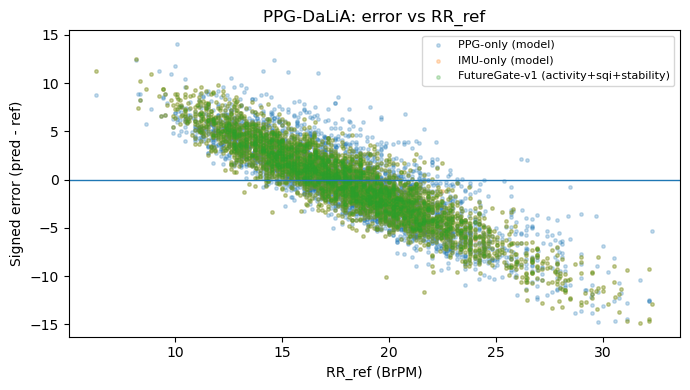

✅ saved fig: C:\Users\yasmi\rr_runs\_tables\future_gate_v1\PPG-DaLiA__bland_altman.png


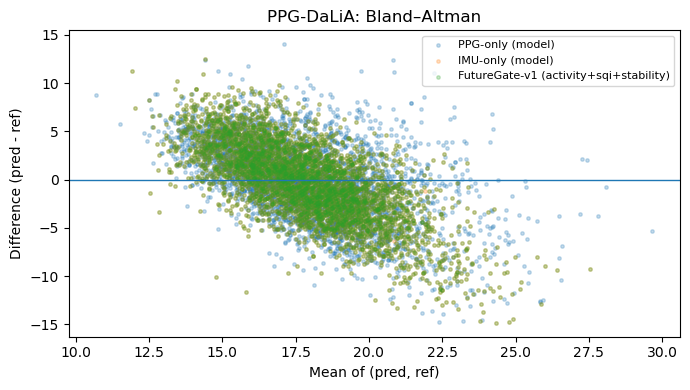

✅ saved fig: C:\Users\yasmi\rr_runs\_tables\future_gate_v1\WESAD__error_vs_rrref.png


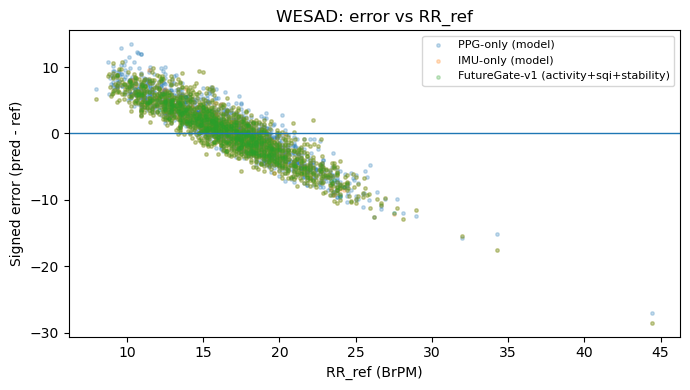

✅ saved fig: C:\Users\yasmi\rr_runs\_tables\future_gate_v1\WESAD__bland_altman.png


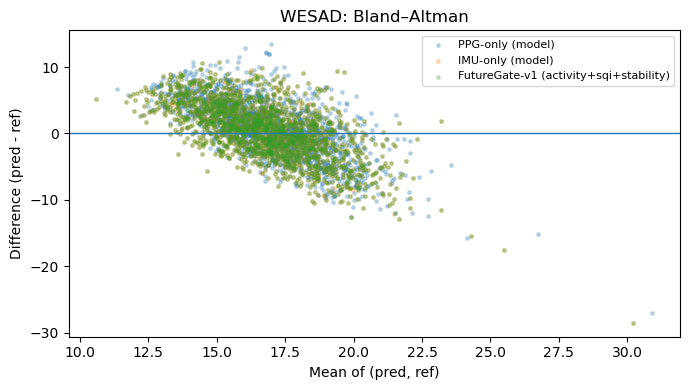

In [32]:
import matplotlib.pyplot as plt

PLOT_METHODS = [
    ("PPG-only (model)", "rr_ppg"),
    ("IMU-only (model)", "rr_imu"),
    ("FutureGate-v1 (activity+sqi+stability)", "rr_gate"),
]

def savefig(path):
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, path), dpi=200)
    print("✅ saved fig:", os.path.join(OUTDIR, path))

for ds in sorted(df2["dataset"].unique()):
    d = df2[df2["dataset"]==ds].dropna(subset=["rr_ref"]).copy()

    # ---- Error vs RR_ref ----
    plt.figure(figsize=(7,4))
    for name, col in PLOT_METHODS:
        dd = d.dropna(subset=[col]).copy()
        err = dd[col].values - dd["rr_ref"].values
        plt.scatter(dd["rr_ref"].values, err, s=6, alpha=0.25, label=name)
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("RR_ref (BrPM)")
    plt.ylabel("Signed error (pred - ref)")
    plt.title(f"{ds}: error vs RR_ref")
    plt.legend(fontsize=8)
    savefig(f"{ds}__error_vs_rrref.png")
    plt.show()

    # ---- Bland–Altman ----
    plt.figure(figsize=(7,4))
    for name, col in PLOT_METHODS:
        dd = d.dropna(subset=[col]).copy()
        mean = 0.5*(dd[col].values + dd["rr_ref"].values)
        diff = (dd[col].values - dd["rr_ref"].values)
        plt.scatter(mean, diff, s=6, alpha=0.25, label=name)
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("Mean of (pred, ref)")
    plt.ylabel("Difference (pred - ref)")
    plt.title(f"{ds}: Bland–Altman")
    plt.legend(fontsize=8)
    savefig(f"{ds}__bland_altman.png")
    plt.show()


In [36]:
import os, pandas as pd

ROOT = r"C:\Users\yasmi\rr_runs"
FINAL = os.path.join(ROOT, "_tables", "final_eval")

paths = {
    "overall_window_weighted": os.path.join(FINAL, "overall_window_weighted.csv"),
    "overall_per_subject_mean_std": os.path.join(FINAL, "overall_per_subject_mean_std.csv"),
    "activity_stratified_table": os.path.join(FINAL, "activity_stratified_table.csv"),
    "coverage_tradeoff_table": os.path.join(FINAL, "coverage_tradeoff_table.csv"),
    "motion_stratified_table": os.path.join(FINAL, "motion_stratified_table.csv"),
}

print("=== Expected outputs ===")
for k,p in paths.items():
    print(f"{k:28s} exists={os.path.exists(p)}  -> {p}")

def show(name, n=12):
    p = paths[name]
    if not os.path.exists(p):
        print(f"\n❌ Missing: {p}")
        return None
    df = pd.read_csv(p)
    print(f"\n=== {name} ({len(df)} rows) ===")
    print(df.head(n))
    return df

overall = show("overall_window_weighted")
act     = show("activity_stratified_table")
cov     = show("coverage_tradeoff_table")
mot     = show("motion_stratified_table")


=== Expected outputs ===
overall_window_weighted      exists=True  -> C:\Users\yasmi\rr_runs\_tables\final_eval\overall_window_weighted.csv
overall_per_subject_mean_std exists=True  -> C:\Users\yasmi\rr_runs\_tables\final_eval\overall_per_subject_mean_std.csv
activity_stratified_table    exists=True  -> C:\Users\yasmi\rr_runs\_tables\final_eval\activity_stratified_table.csv
coverage_tradeoff_table      exists=True  -> C:\Users\yasmi\rr_runs\_tables\final_eval\coverage_tradeoff_table.csv
motion_stratified_table      exists=True  -> C:\Users\yasmi\rr_runs\_tables\final_eval\motion_stratified_table.csv

=== overall_window_weighted (10 rows) ===
                          method    dataset       N        MAE       RMSE  \
0                  kazemi_strong  PPG-DaLiA  3883.0   3.227728   4.049559   
1                  kazemi_strong      WESAD  1797.0   3.384639   4.258714   
2     pimentel_baseline_ppg_only  PPG-DaLiA  3417.0  13.290224  18.242279   
3     pimentel_baseline_ppg_only      WESA

✅ wrote C:\Users\yasmi\rr_runs\_tables\swi_plots\swi_per_window.csv | rows: 5680
✅ saved overall: C:\Users\yasmi\rr_runs\_tables\swi_plots\overall_swi_vs_models.csv


,dataset,method,N,MAE,RMSE,pct_abs_err_le_3
0,PPG-DaLiA,PPG-only (model),3883.0,3.230085,4.045323,0.528200
1,PPG-DaLiA,IMU-only (model),3883.0,3.152103,3.974933,0.559104
2,PPG-DaLiA,SWI-gated,3883.0,3.152442,3.978245,0.559361
3,WESAD,PPG-only (model),1797.0,3.380139,4.277095,0.517529
4,WESAD,IMU-only (model),1797.0,3.333357,4.189065,0.524207
5,WESAD,SWI-gated,1797.0,3.318991,4.169963,0.526433


✅ saved motion: C:\Users\yasmi\rr_runs\_tables\swi_plots\motion_stratified_swi_vs_models.csv
✅ saved activity: C:\Users\yasmi\rr_runs\_tables\swi_plots\activity_stratified_swi_vs_models.csv
✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\PPG-DaLiA__overall_mae_bar.png


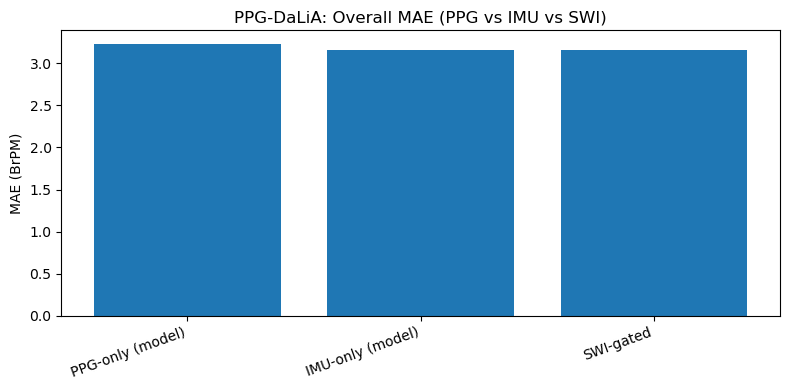

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\WESAD__overall_mae_bar.png


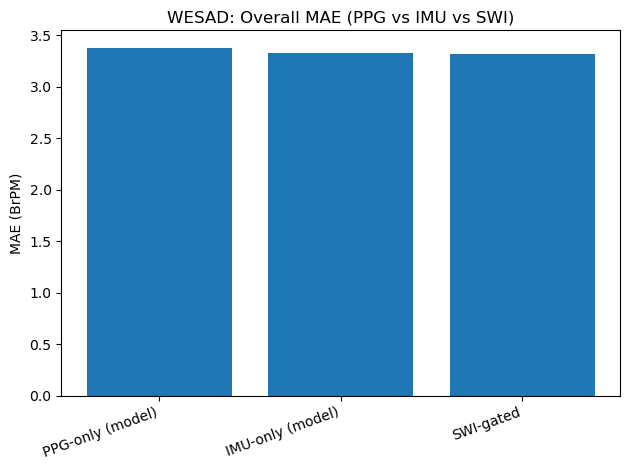

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\PPG-DaLiA__mae_by_motion_lines.png


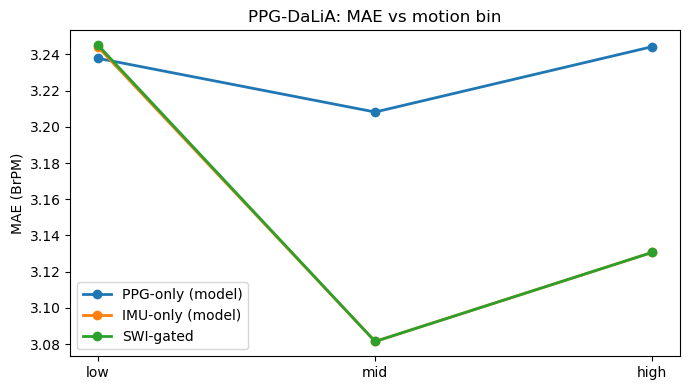

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\WESAD__mae_by_motion_lines.png


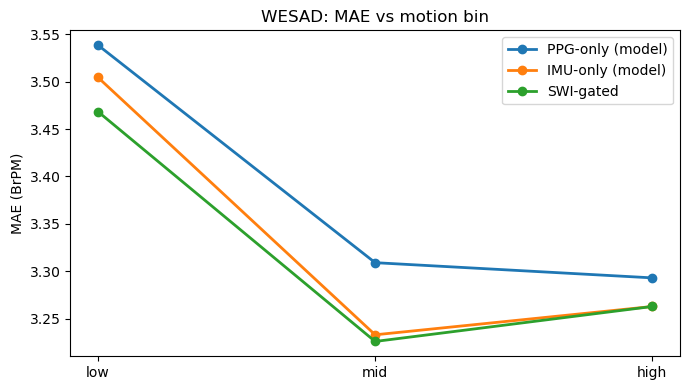

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\PPG-DaLiA__mae_by_activityid_lines.png


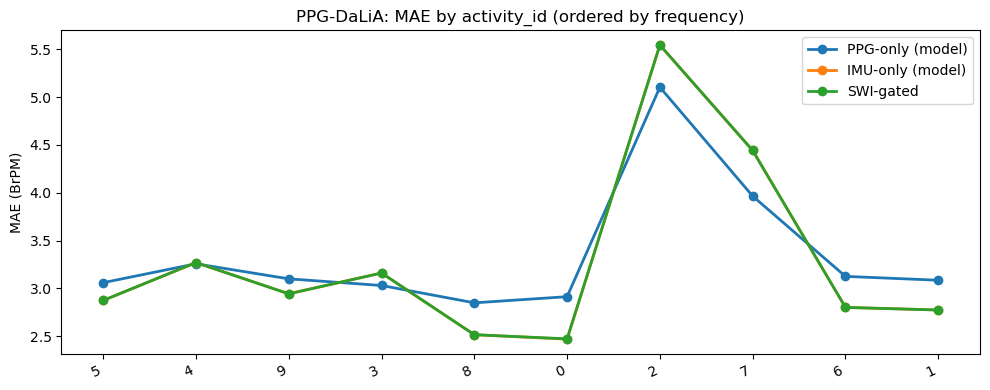

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\WESAD__mae_by_activityid_lines.png


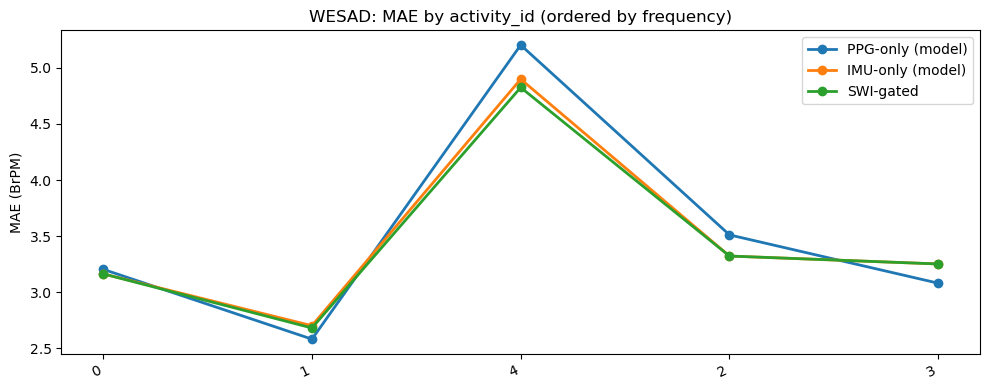

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\PPG-DaLiA__err_vs_rrref__PPG.png


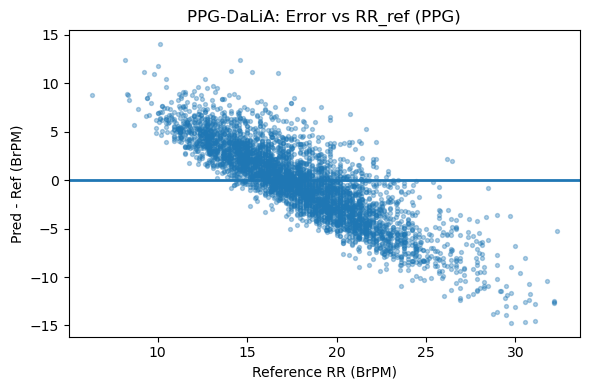

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\PPG-DaLiA__bland_altman__PPG.png


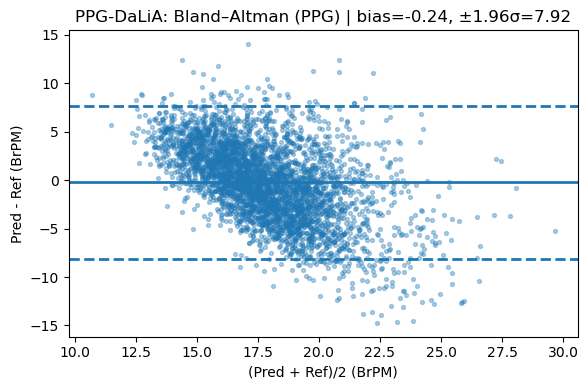

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\PPG-DaLiA__err_vs_rrref__IMU.png


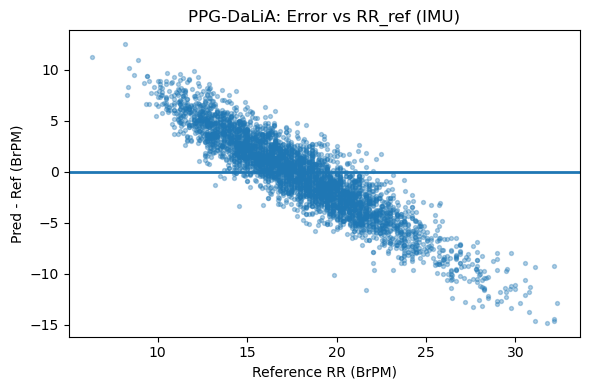

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\PPG-DaLiA__bland_altman__IMU.png


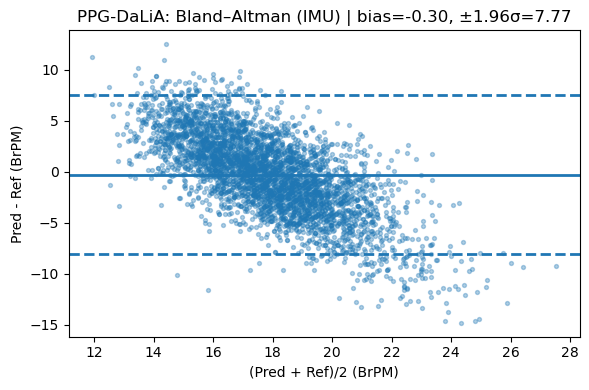

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\PPG-DaLiA__err_vs_rrref__SWI.png


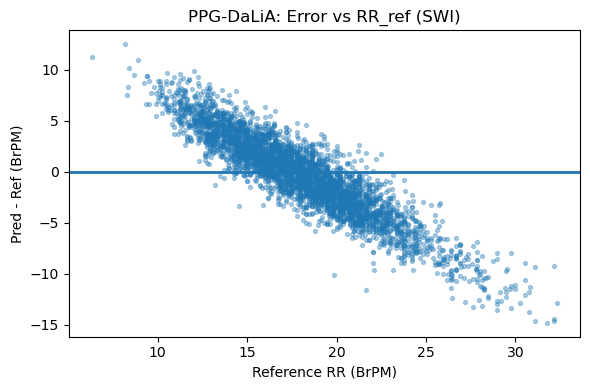

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\PPG-DaLiA__bland_altman__SWI.png


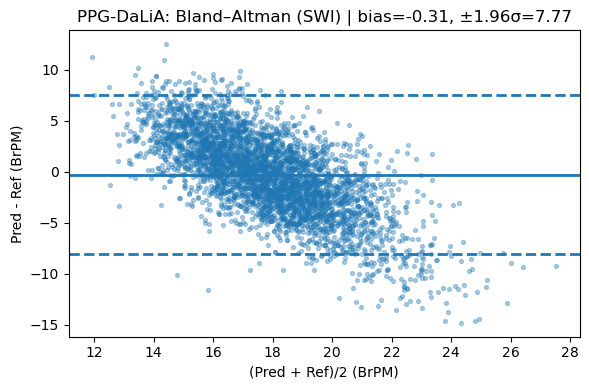

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\WESAD__err_vs_rrref__PPG.png


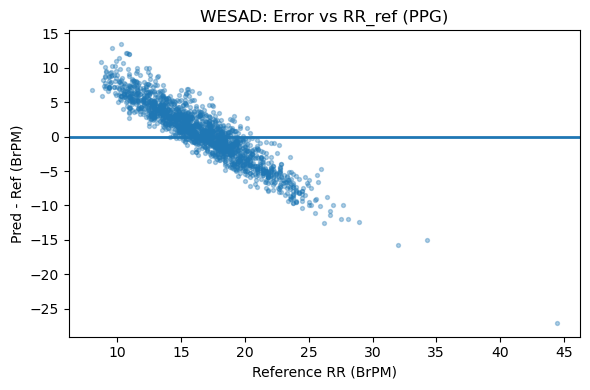

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\WESAD__bland_altman__PPG.png


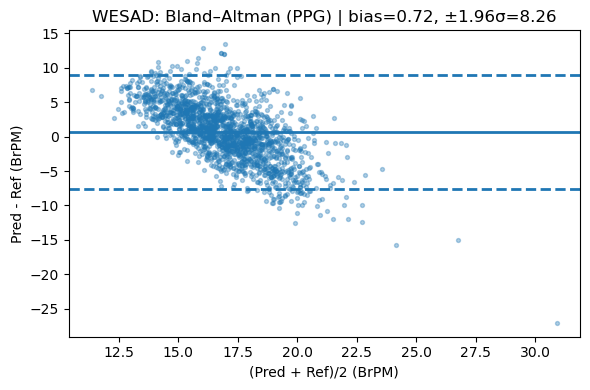

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\WESAD__err_vs_rrref__IMU.png


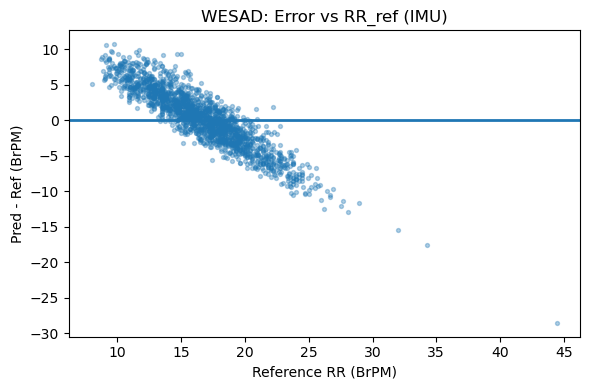

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\WESAD__bland_altman__IMU.png


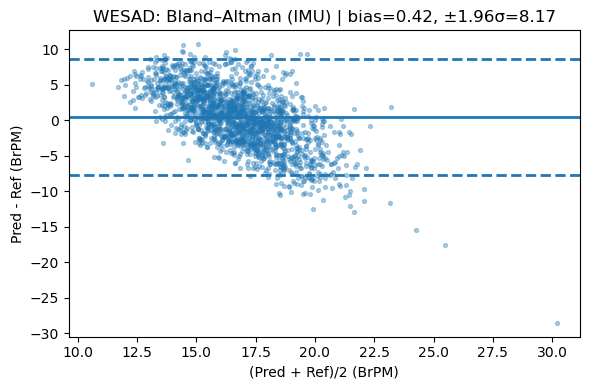

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\WESAD__err_vs_rrref__SWI.png


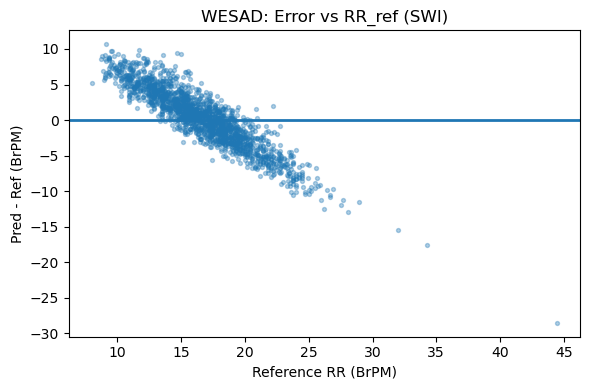

✅ saved figure: C:\Users\yasmi\rr_runs\_tables\swi_plots\WESAD__bland_altman__SWI.png


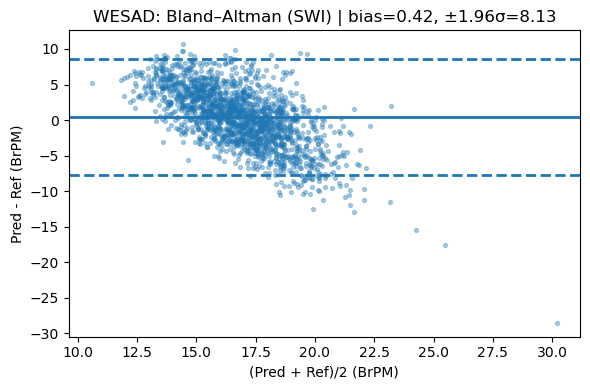


Done. All tables + plots saved in: C:\Users\yasmi\rr_runs\_tables\swi_plots
Key outputs:
 - overall_swi_vs_models.csv
 - motion_stratified_swi_vs_models.csv
 - activity_stratified_swi_vs_models.csv
 - figures *.png


In [1]:
# SWI / gating graphs (PPG-only vs IMU-only vs SWI-gated)
# Drop into a new notebook cell. It will:
# 1) load your three CSVs (ppg/imu/swi per-window)
# 2) compute overall + motion/activity stratified tables
# 3) save clean plots (no Pimentel/Kazemi unless you add them)

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# ========= EDIT THESE PATHS =========
CSV_PPG = r"C:\Users\yasmi\rr_runs\_tables\learned_swi_gate\combined_for_learned_gate.csv"
# If you already have a per-window file that includes SWI-gated rr_pred, set it here.
# Otherwise, we will create SWI predictions from rr_pred__ppg / rr_pred__imu using a rule below.
CSV_OUTDIR = r"C:\Users\yasmi\rr_runs\_tables\swi_plots"
os.makedirs(CSV_OUTDIR, exist_ok=True)

# ========= Load combined table (must include rr_ref, sqi01, motion, activity_id, and both preds) =========
df = pd.read_csv(CSV_PPG)

# Detect your columns (matches what you printed)
COL_RR_REF = "rr_ref"
COL_PPG = None
COL_IMU = None

for c in df.columns:
    if c.startswith("rr_pred__") and "ppg" in c.lower():
        COL_PPG = c
    if c.startswith("rr_pred__") and "imu" in c.lower():
        COL_IMU = c

need = {"dataset","subject_id","window_index",COL_RR_REF,"sqi01","motion","activity_id",COL_PPG,COL_IMU}
missing = [x for x in need if (x is None) or (x not in df.columns)]
assert len(missing)==0, f"Missing required columns: {missing}\nHave: {list(df.columns)}"

# Rename to clean names for plotting code
df = df.rename(columns={COL_PPG:"rr_ppg", COL_IMU:"rr_imu", COL_RR_REF:"rr_ref"}).copy()

# ========= Define SWI gate (EDIT thresholds here) =========
# Goal: use PPG rarely and only when plausibly helpful:
# - good sqi
# - low motion
# - stable PPG (not jumping)
# - optional: low-motion activities (DaLiA mapping already exists as activity_id)
ROLL_K = 9
SQI_T = 0.55
MOTION_T = 0.40
JUMP_T = 2.5     # BrPM jump from rolling median
GAP_T  = 4.0     # if PPG and IMU disagree too much, default to IMU

df2 = df.sort_values(["dataset","subject_id","window_index"]).copy()

df2["ppg_roll_med"] = (
    df2.groupby(["dataset","subject_id"])["rr_ppg"]
       .transform(lambda s: s.rolling(ROLL_K, center=True, min_periods=1).median())
)
df2["ppg_jump"] = (df2["rr_ppg"] - df2["ppg_roll_med"]).abs()
df2["ppg_imu_gap"] = (df2["rr_ppg"] - df2["rr_imu"]).abs()

# Low-motion / calm activity sets (EDIT if you want)
# WESAD ids are known: 0 Transit, 1 Baseline, 2 Stress, 3 Amusement, 4 Meditation
WESAD_CALM = {1,4}         # baseline + meditation (choose what you want)
# DaLiA ids are your inferred ones (not perfect): BASELINE, WALKING etc.
# If you have activity_name column, you can gate on names too later.
DALIA_CALM = {0,8,9,4}     # baseline, walking, working, lunch (edit)

is_calm = np.where(
    df2["dataset"].eq("WESAD"),
    df2["activity_id"].isin(WESAD_CALM),
    df2["activity_id"].isin(DALIA_CALM)
)

use_ppg = (
    (df2["sqi01"] >= SQI_T) &
    (df2["motion"] <= MOTION_T) &
    (df2["ppg_jump"] <= JUMP_T) &
    (df2["ppg_imu_gap"] <= GAP_T) &
    is_calm
)

df2["gate_choice"] = np.where(use_ppg, "PPG", "IMU")
df2["rr_swi"] = np.where(use_ppg, df2["rr_ppg"], df2["rr_imu"])

# Save per-window gated file
out_win = os.path.join(CSV_OUTDIR, "swi_per_window.csv")
df2.to_csv(out_win, index=False)
print("✅ wrote", out_win, "| rows:", len(df2))

# ========= Metrics helpers =========
def metrics_from_windows(d):
    e = (d["rr_ref"] - d["rr_pred"]).abs().to_numpy()
    mae = float(np.mean(e))
    rmse = float(np.sqrt(np.mean(e**2)))
    pct3 = float(np.mean(e <= 3.0))
    return pd.Series({"N":len(d), "MAE":mae, "RMSE":rmse, "pct_abs_err_le_3":pct3})

def overall_table(df_in):
    rows=[]
    for ds in sorted(df_in["dataset"].unique()):
        for method, col in [("PPG-only (model)","rr_ppg"), ("IMU-only (model)","rr_imu"), ("SWI-gated","rr_swi")]:
            d = df_in[df_in["dataset"]==ds].copy()
            d = d.rename(columns={col:"rr_pred"})
            m = metrics_from_windows(d)
            rows.append({"dataset":ds,"method":method, **m.to_dict()})
    return pd.DataFrame(rows)

def motion_bins(d):
    # terciles per dataset
    q1 = d["motion"].quantile(1/3)
    q2 = d["motion"].quantile(2/3)
    return q1, q2

# ========= Tables =========
tab_overall = overall_table(df2)
tab_overall.to_csv(os.path.join(CSV_OUTDIR, "overall_swi_vs_models.csv"), index=False)
print("✅ saved overall:", os.path.join(CSV_OUTDIR, "overall_swi_vs_models.csv"))
display(tab_overall)

# motion stratified
rows=[]
for ds in sorted(df2["dataset"].unique()):
    dd = df2[df2["dataset"]==ds].copy()
    q1,q2 = motion_bins(dd)
    dd["motion_bin"] = pd.cut(dd["motion"], bins=[-np.inf,q1,q2,np.inf], labels=["low","mid","high"])
    for method, col in [("PPG-only (model)","rr_ppg"), ("IMU-only (model)","rr_imu"), ("SWI-gated","rr_swi")]:
        tmp = dd.rename(columns={col:"rr_pred"})
        for b in ["low","mid","high"]:
            m = metrics_from_windows(tmp[tmp["motion_bin"]==b])
            rows.append({"dataset":ds,"method":method,"motion_bin":b,**m.to_dict()})
        m = metrics_from_windows(tmp)
        rows.append({"dataset":ds,"method":method,"motion_bin":"all",**m.to_dict()})

tab_motion = pd.DataFrame(rows)
tab_motion.to_csv(os.path.join(CSV_OUTDIR, "motion_stratified_swi_vs_models.csv"), index=False)
print("✅ saved motion:", os.path.join(CSV_OUTDIR, "motion_stratified_swi_vs_models.csv"))

# activity stratified (by activity_id; if you have activity_name column, add it later)
rows=[]
for ds in sorted(df2["dataset"].unique()):
    dd = df2[df2["dataset"]==ds].copy()
    for method, col in [("PPG-only (model)","rr_ppg"), ("IMU-only (model)","rr_imu"), ("SWI-gated","rr_swi")]:
        tmp = dd.rename(columns={col:"rr_pred"})
        for aid, gg in tmp.groupby("activity_id"):
            m = metrics_from_windows(gg)
            rows.append({"dataset":ds,"method":method,"activity_id":aid,**m.to_dict()})
        m = metrics_from_windows(tmp)
        rows.append({"dataset":ds,"method":method,"activity_id":"ALL",**m.to_dict()})

tab_act = pd.DataFrame(rows)
tab_act.to_csv(os.path.join(CSV_OUTDIR, "activity_stratified_swi_vs_models.csv"), index=False)
print("✅ saved activity:", os.path.join(CSV_OUTDIR, "activity_stratified_swi_vs_models.csv"))

# ========= Plots (saved) =========
def savefig(name):
    path = os.path.join(CSV_OUTDIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("✅ saved figure:", path)

# Plot 1: Overall MAE bars
plt.figure(figsize=(8,4))
for i,ds in enumerate(sorted(df2["dataset"].unique())):
    sub = tab_overall[tab_overall["dataset"]==ds].set_index("method").loc[["PPG-only (model)","IMU-only (model)","SWI-gated"]]
    x = np.arange(len(sub)) + i*(len(sub)+1)
    plt.bar(x, sub["MAE"].values)
    plt.xticks(x, sub.index, rotation=20, ha="right")
    plt.title(f"{ds}: Overall MAE (PPG vs IMU vs SWI)")
    plt.ylabel("MAE (BrPM)")
    savefig(f"{ds}__overall_mae_bar.png")
    plt.show()

# Plot 2: Motion lines (MAE)
for ds in sorted(df2["dataset"].unique()):
    dd = tab_motion[(tab_motion["dataset"]==ds) & (tab_motion["motion_bin"]!="all")].copy()
    order = ["low","mid","high"]
    plt.figure(figsize=(7,4))
    for m in ["PPG-only (model)","IMU-only (model)","SWI-gated"]:
        g = dd[dd["method"]==m].set_index("motion_bin").reindex(order)
        plt.plot(order, g["MAE"].values, marker="o", linewidth=2, label=m)
    plt.title(f"{ds}: MAE vs motion bin")
    plt.ylabel("MAE (BrPM)")
    plt.legend()
    savefig(f"{ds}__mae_by_motion_lines.png")
    plt.show()

# Plot 3: Activity lines (MAE) — simple by activity_id
for ds in sorted(df2["dataset"].unique()):
    dd = tab_act[(tab_act["dataset"]==ds) & (tab_act["activity_id"]!="ALL")].copy()
    # order by frequency
    order = df2[df2["dataset"]==ds].groupby("activity_id").size().sort_values(ascending=False).index.tolist()
    plt.figure(figsize=(10,4))
    for m in ["PPG-only (model)","IMU-only (model)","SWI-gated"]:
        g = dd[dd["method"]==m].set_index("activity_id").reindex(order)
        plt.plot([str(x) for x in order], g["MAE"].values, marker="o", linewidth=2, label=m)
    plt.xticks(rotation=25, ha="right")
    plt.title(f"{ds}: MAE by activity_id (ordered by frequency)")
    plt.ylabel("MAE (BrPM)")
    plt.legend()
    savefig(f"{ds}__mae_by_activityid_lines.png")
    plt.show()

# Plot 4: Bland–Altman + error vs RR_ref (SWI vs IMU vs PPG) — saved per dataset
for ds in sorted(df2["dataset"].unique()):
    d = df2[df2["dataset"]==ds].copy()
    for name, col in [("PPG","rr_ppg"),("IMU","rr_imu"),("SWI","rr_swi")]:
        pred = d[col].to_numpy()
        ref = d["rr_ref"].to_numpy()
        err = pred - ref

        # error vs rr_ref
        plt.figure(figsize=(6,4))
        plt.scatter(ref, err, s=8, alpha=0.35)
        plt.axhline(0, linewidth=2)
        plt.xlabel("Reference RR (BrPM)")
        plt.ylabel("Pred - Ref (BrPM)")
        plt.title(f"{ds}: Error vs RR_ref ({name})")
        savefig(f"{ds}__err_vs_rrref__{name}.png")
        plt.show()

        # Bland–Altman
        mean = 0.5*(pred+ref)
        plt.figure(figsize=(6,4))
        plt.scatter(mean, err, s=8, alpha=0.35)
        bias = float(np.mean(err))
        loa = 1.96*float(np.std(err))
        plt.axhline(bias, linewidth=2)
        plt.axhline(bias+loa, linestyle="--", linewidth=2)
        plt.axhline(bias-loa, linestyle="--", linewidth=2)
        plt.xlabel("(Pred + Ref)/2 (BrPM)")
        plt.ylabel("Pred - Ref (BrPM)")
        plt.title(f"{ds}: Bland–Altman ({name}) | bias={bias:.2f}, ±1.96σ={loa:.2f}")
        savefig(f"{ds}__bland_altman__{name}.png")
        plt.show()

print("\nDone. All tables + plots saved in:", CSV_OUTDIR)
print("Key outputs:")
print(" - overall_swi_vs_models.csv")
print(" - motion_stratified_swi_vs_models.csv")
print(" - activity_stratified_swi_vs_models.csv")
print(" - figures *.png")
